# Proyecto Final: Pipeline Integral de Ciencia de Datos & IA
**Asignatura:** Ciencia de Datos / Inteligencia Artificial  
**Integrantes:** Roy Umaña,Jose Martin,Joseph Valerio 
**Dataset Seleccionado:** Conjunto de datos de aprobación de préstamos
**Enlace de Kaggle:** https://www.kaggle.com/datasets/rohitgrewal/loan-approval-dataset?resource=download
---

## Fase 1: Formulación del Problema y Gobernanza de Datos

### 1.1 Ficha Técnica del Negocio
* **Contexto Operativo:** (Conjunto de datos de aprobación de préstamos).
* **Tipo de Problema Predictivo:** [Clasificación Binaria] 
* **Variable Objetivo ($Y$):** `estado_del_prestamo` (`Categorica Binaria - Aprobado o no aprobado`)
* **Variables Predictoras Clave ($X$):** `puntaje_civil(clave), ingresos anuales(clave), monto_del_prestamo(clave), plazo_del_prestamo(clave), valor_activos_residenciales(clave), valor_activos_comerciales(clave), valor_activos_de_lujo(clave), valor_activos_bancarios(clave), educacion, trabajador_independiente, numero_de_independientes`

### 1.2 Estrategia de Gobernanza y Protección de Datos (PII)
* **Data Owner (Dueño del Dato):** Gerente de credito o gerente de riesgos de la institucion financiera, responsable de autorizar y supervisar el acceso a los datos de los clientes utilizados para el analisis y aprobacion de prestamos
* **Data Steward (Custodio del Dato):** Administrador de datos del area de credito, responsable de supervisar la calidad, integridad,actualizacion y documentacion de los datos , asi como de verificar el cuplimiento de las politicas de manejo de informacion 
* **Estrategia de Privacidad:** (Se aplicaria enmascaramiento parcial para proteger los datos sensibles de los clientes. La informacion identificable, como el id_prestamo, sera parcialmente ocultada para evitar la identificacion directa del cliente, manteniendo unicamente los caracteres necesarios para fines de control y analisis).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib


# 1. CARGA DEL DATASET
df = pd.read_csv('loan_approval_dataset.csv')
print(df.head().to_string(index=False))
# Para propósitos del esqueleto,  DataFrame que reemplazarán:


# 2. PIPELINE DE ENMASCARAMIENTO (La idea es ocultar el identificador original)

#El dataset contiene loan_id, que es un identificador del prestamo. Para proteger este identificador se aplicara enmascaramiento
#conservando unicamente los ultimos 2 caracteres 
def enmascarar_loan_id(loan_id):
    
    #aqui se convierte el  id a texto
    loan_id=str(loan_id)
    return "LOAN-****-"+loan_id[-2:]

#crear la copia del identificador original antes de modificarlo
df["loan_id_enmascarado"]=df["loan_id"].apply(enmascarar_loan_id)

#eliminar el identificador original para protegerlo
df_anonimizado=df.drop(columns=['loan_id'])

#primeros registros
print("=="*90)
print("\nDatos despues del enmascaramiento:")
print(df_anonimizado.head().to_string(index=False))


# Sanitización de columna simulada con PII


 loan_id  no_of_dependents     education  self_employed   income_annum   loan_amount   loan_term   cibil_score   residential_assets_value   commercial_assets_value   luxury_assets_value   bank_asset_value  loan_status
       1                 2      Graduate             No        9600000      29900000          12           778                    2400000                  17600000              22700000            8000000     Approved
       2                 0  Not Graduate            Yes        4100000      12200000           8           417                    2700000                   2200000               8800000            3300000     Rejected
       3                 3      Graduate             No        9100000      29700000          20           506                    7100000                   4500000              33300000           12800000     Rejected
       4                 3      Graduate             No        8200000      30700000           8           467                  

--- Auditoría de Valores Nulos ---
                          Valores Nulos  Porcentaje (%)
loan_id                               0             0.0
no_of_dependents                      0             0.0
education                             0             0.0
self_employed                         0             0.0
income_annum                          0             0.0
loan_amount                           0             0.0
loan_term                             0             0.0
cibil_score                           0             0.0
residential_assets_value              0             0.0
commercial_assets_value               0             0.0
luxury_assets_value                   0             0.0
bank_asset_value                      0             0.0
loan_status                           0             0.0
loan_id_enmascarado                   0             0.0
approved_numeric                      0             0.0

Total de registros duplicados detectados: 0

--- Medidas de Tendenci

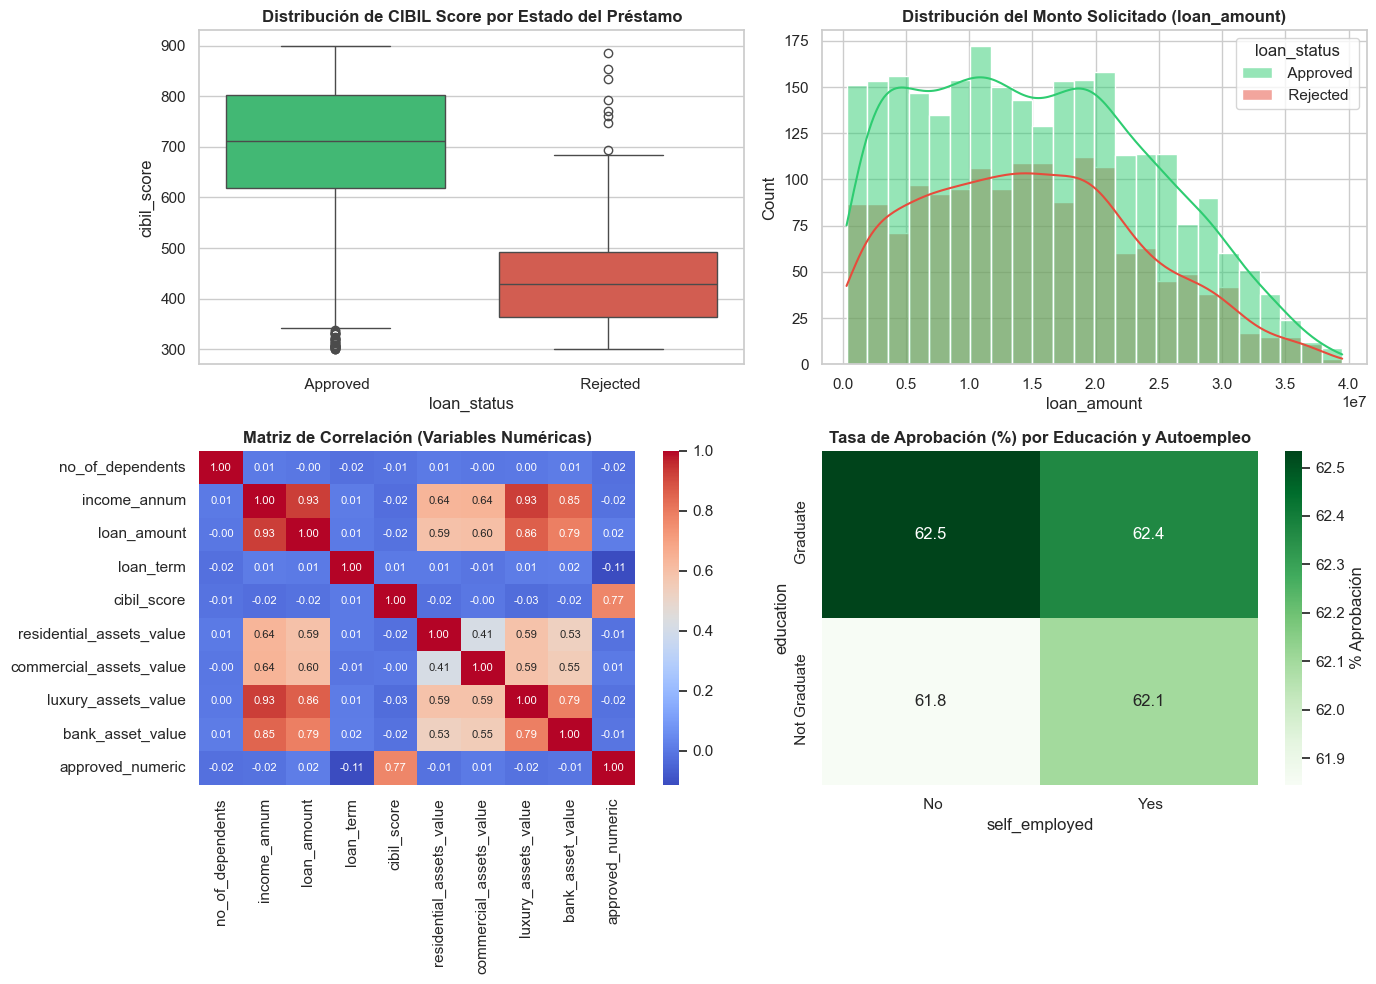

In [15]:
# 2.1 Auditoría de Calidad: Nulos y Duplicados
df.columns = df.columns.str.strip()

# 1. Cuantificación de Nulos
nulls_df = pd.DataFrame({
    'Valores Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df)) * 100
})
print("--- Auditoría de Valores Nulos ---")
print(nulls_df)

# 2. Verificación y Eliminación de Duplicados
duplicates_count = df.duplicated().sum()
print(f"\nTotal de registros duplicados detectados: {duplicates_count}")

#2.2 Medidas de tendencia central, Dispersion y asimetria  de la variable principal. Se analiza loan_amount(variable principal del negocio) junto con 
#las variables de activos 
variables_analisis=['loan_amount', 'residential_assets_value', 'commercial_assets_value']

resumen_estadistico=pd.DataFrame({'Media': df[variables_analisis].mean(),
                                  'Mediana':df[variables_analisis].median(),
                                  'Desviacion Estandar ':df[variables_analisis].std(),
                                  'Rango Intercuartilico (IQR)':df[variables_analisis].quantile(0.75)-df[variables_analisis].quantile(0.25),
                                  'Asimetria':df[variables_analisis].skew()}).round(2)


print("\n--- Medidas de Tendencia Central, Dispersion y Asimetria ---")
print(resumen_estadistico)

# 2.3 Segmentación Explicativa: GroupBy / Pivot Table
pivot_summary = df.pivot_table(
    index=['education', 'self_employed'],
    columns='loan_status',
    values=['loan_amount', 'income_annum', 'cibil_score'],
    aggfunc={'loan_amount': 'mean', 'income_annum': 'mean', 'cibil_score': 'mean'}
)

print(pivot_summary.round(2))

# 2.4 Visualización Diagnóstica
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot: CIBIL Score por Estado de Préstamo
sns.boxplot(
    data=df, 
    x='loan_status', 
    y='cibil_score', 
    hue='loan_status',
    palette=['#2ecc71', '#e74c3c'], 
    legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Distribución de CIBIL Score por Estado del Préstamo', fontweight='bold')

# 2. Histograma: Distribución del Monto del Préstamo
sns.histplot(data=df, x='loan_amount', hue='loan_status', kde=True, palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1])
axes[0, 1].set_title('Distribución del Monto Solicitado (loan_amount)', fontweight='bold')

# 3. Heatmap: Matriz de Correlaciones Numéricas
numeric_cols = df.select_dtypes(include=['number']).drop(columns=['loan_id'])
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 0], annot_kws={"size": 8})
axes[1, 0].set_title('Matriz de Correlación (Variables Numéricas)', fontweight='bold')

# 4. Heatmap: Tasa de Aprobación (%) por Educación y Empleo Independiente
df['approved_numeric'] = df['loan_status'].str.strip().apply(lambda x: 1 if x == 'Approved' else 0)
pivot_approval = df.pivot_table(index='education', columns='self_employed', values='approved_numeric', aggfunc='mean') * 100
sns.heatmap(pivot_approval, annot=True, fmt='.1f', cmap='Greens', ax=axes[1, 1], cbar_kws={'label': '% Aprobación'})
axes[1, 1].set_title('Tasa de Aprobación (%) por Educación y Autoempleo', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretación Técnica del Diagnóstico EDA
Conclusiones del análisis visual:

La variable loan_amount presenta una ligera asimetría positiva (0.31), mientras que los activos residenciales (0.98) y comerciales (0.96) muestran una alta asimetría positiva. 

Valores atípicos: Se detectaron outliers en el boxplot de cibil_score (34 aprobados con puntajes atípicamente bajos < 350 y 8 rechazados con puntajes > 680, además de valores atípicos en los activos residenciales (52 casos) y comerciales (37 casos).

Dispersión de montos: La mayor dispersión en los montos solicitados (loan_amount) se concentra en los préstamos aprobados (Approved), registrando una mayor desviación estándar (std = 9.22M$) y rango intercuartílico (IQR = 14.6M$) frente a los rechazados.

---
## Fase 3: Modelado Estadístico y Capacidad de Generalización

En esta sección debes:

1. Comparar **dos modelos competidores** (ej. Regresión Logística vs. Árbol de Decisión; o Regresión Lineal vs. Ridge/Lasso).
2. Validar con **$5$-Fold Cross-Validation** sobre el conjunto de entrenamiento.
3. Comparar el rendimiento de Train vs. Test para diagnosticar si existe **Overfitting (Alta Varianza)** o **Underfitting (Alto Sesgo)**.


---
## Importaciones nuevas

1. En esta parte agregue la libreria de **StratifiedKFold**, porque el problema es de *clasificacion binaria*, porque mantiene la proporcion de Aprovado y rechazado

2. La regresion logistica tendra escalamiento, las variables tienen escalas muy diferentes 


        ingresos -> millones
        monto_prestamo  -> millones
        Plazo del prestamo   -> decenas
        Puntaje crediticio -> cientos
        Personas a cargo: representa la cantidad de miembros de la familia que dependen económicamente del solicitante (hijos, cónyuge, adultos mayores, etc.) -> pocos valores

    por eso se utiliza **StandardScaler()**

3. Antes de la regresion logistica se hace mendiante **Pipeline** para que el escalamiento se haga correctamente dentro de cada entrenamiento y validacion, evitando fuga de informacion


--- 

## Explicacion de uso Regresion Logistica vs Arbol de decision

Aqui la regresion logistica es apropiada porque intenta determinar la probabilidad de pertenecer a una clase.

El arbol de decision funciona de manera diferente. Va creado reglas de decisiion a partir de las variables 

```text
       ¿CIBIL > cierto valor?
              /     \
             /       \
            Sí        No
           /           \
     Aprobado        Rechazado
```
---

# Diferencia entre Regresion Logistica y Arbol de decision

**un árbol de decisión divide los datos en múltiples regiones usando reglas jerárquicas en forma de diagrama, mientras que la regresión logística calcula una única línea (o plano) de separación basada en probabilidades continuas**

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score

# 3.1 Preparación de Variables
df_modelo=df_anonimizado.copy()

#aqui se eliminan los espacios al inciio y al final de los nombres de columnas
df_modelo.columns=df_modelo.columns.str.strip()

#aqui se convierten las variables categoricas a variables numericas 
df_modelo=pd.get_dummies(df_modelo,columns=['education','self_employed'],drop_first=True)

#variable objetivo
y=df_modelo['loan_status']

#Variables predictoras
X=df_modelo.drop(columns=['loan_status','loan_id_enmascarado'])

print("Variables Predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

#Division train/test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("\nTamaño del conjunto de entrenamiento: ",X_train.shape)
print("Tamaño del conjunto de prueba: ",X_test.shape)

# 3.2 Definición de Modelos Competidores

#Modelo 1 - Regresion logistica
modelo_logistico=Pipeline([('escalado',StandardScaler()),('modelo',LogisticRegression(max_iter=1000,random_state=42))])

#Modelo 2: Arbol de decision
modelo_arbol=DecisionTreeClassifier(max_depth=5,random_state=42)#ver

# 3.3 Validación Cruzada (5-Fold CV sobre Train) y Entrenamiento de modelos
modelo_logistico.fit(X_train,y_train)
modelo_arbol.fit(X_train,y_train)
print("\nModelos entrenados correctamente")

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

#Regresion logistica
scores_logistico=cross_val_score(modelo_logistico,X_train,y_train,cv=cv,scoring='accuracy')

#Arbol de decision
scores_arbol=cross_val_score(modelo_arbol,X_train,y_train,cv=cv,scoring='accuracy')

print("\n====================== VALIDACION CRUZADA 5-FOLD ====================")
print("\nRegresion Logistica: ")
print("Resultados de cada Fold: ",scores_logistico)
print(f"Accuracy promedio: {scores_logistico.mean():4f}")#ver
print(f"Desviación estandar: {scores_logistico.std():.4f}")

print("\nArbol de Decision:")
print("Resultados de cada Fold:", scores_arbol)
print(f"Accuracy promedio: {scores_arbol.mean():.4f}")
print(f"Desviacion estandar: {scores_arbol.std():.4f}")



# 3.4 Diagnóstico Train vs. Test (Detección de Sesgo / Varianza)

#Predicciones del conjunto de entrenamiento 
y_train_pred_log=modelo_logistico.predict(X_train)
y_train_pred_arbol=modelo_arbol.predict(X_train)

#Predicciones del conjutno de prueba
y_test_pred_log=modelo_logistico.predict(X_test)
y_test_pred_arbol=modelo_arbol.predict(X_test)

#Accuracy de precision
train_acc_log=accuracy_score(y_train,y_train_pred_log)
train_acc_arbol=accuracy_score(y_train,y_train_pred_arbol)

#Accuracy de precision
test_acc_log=accuracy_score(y_test,y_test_pred_log)
test_acc_arbol=accuracy_score(y_test,y_test_pred_arbol)

print("\n ======= DIAGNOSTICO TRAIN VS TEST =======")

print("\nRegresion Logistica:")
print(f"Accuracy de Train: {train_acc_log:.4f}")
print(f"Accuracy de Test: {test_acc_log:.4f}")
print(f"Diferencia absoluta: {abs(train_acc_log-test_acc_log):.4f}")

print("\nArbol de decision:")
print(f"Accuracy de Train: {train_acc_arbol:.4f}")
print(f"Accuracy de Test: {test_acc_arbol:.4f}")
print(f"Diferencia absoluta: {abs(train_acc_arbol-test_acc_arbol):.4f}")


Variables Predictoras:
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_ Not Graduate', 'self_employed_ Yes']

Variable objetivo:
loan_status

Tamaño del conjunto de entrenamiento:  (3415, 11)
Tamaño del conjunto de prueba:  (854, 11)

Modelos entrenados correctamente

====================== VALIDACION CRUZADA 5-FOLD ====================

Regresion Logistica: 
Resultados de cada Fold:  [0.89604685 0.91215227 0.93704246 0.91215227 0.90483163]
Accuracy promedio: 0.912445
Desviación estandar: 0.0137

Arbol de Decision:
Resultados de cada Fold: [0.97364568 0.96632504 0.97071742 0.95754026 0.96046852]
Accuracy promedio: 0.9657
Desviacion estandar: 0.0060

 ======= DIAGNOSTICO TRAIN VS TEST =======

Regresion Logistica:
Accuracy de Train: 0.9145
Accuracy de Test: 0.9227
Diferencia absoluta: 0.0082

Arbol de decision:
Accuracy de Train: 0.9728
Accuracy de

### Diagnóstico de Complejidad (Sesgo vs. Varianza)
> **Veredicto Técnico:** 

**Regresion Logistica:**
El modelo obtuvo un Accuracy de 0.9145 en el conjunto de entrenamiento y de 0.9227 en el conjunto de prueba. La diferencia entre ambos fue de 0.0082, equivalente a 0.82 puntos porcentuales. Esta diferencia es pequeña, por lo que no se observa una señal evidente de sobreajuste.

En la validacion cruzada 5-Fold, la regresion logistica obtuvo un accuracy promedio de 0.91245, con una desviacion estandar de 0.0137, mostrando una variacion moderada entre las diferentes particiones.

**Arbol de decision**:
El modelo obtuvo un Accuracy de 0.9728 en el conjunto de entrenamiento y de 0.9766 en el conjunto de prueba. La diferencia absoluta fue de 0.0038, equivalente a 0.38 puntos porcentuales. La diferencia reducida entre Train y Test indica un comportamiento similar entre ambos conjuntos y no presenta una señal evidente de sobreajuste en esta evaluación.

En la validacion cruzada 5-Fold, el Arbol de decision obtuvo un Acurracy promedio de 0.9657 y una desviacion estandar de 0.0060, indicando una variacion reducida entre Train y Test indica un comportamiento similar entre ambos conjuntos y no presenta una señal evidente de sobreajuste en esta evaluación.

**Conclusion del diagnostico:**
Ambos modelos presentan diferencias pequeñas entre el rendimiento de entrenamiento y prueba, por lo que no se oberva evidencia clara de sobreajuste en esta evaluacion. La validacion cruzada tambien muestra que el rendimiento se mantiene relativamente estable entre las diferentes particiones del conjutno de entrenamiento.

---
## Fase 4: Traducción a Métricas Financieras y de Negocio

En esta sección debes:
1. Desplegar la Matriz de Confusión y reporte de clasificación (si es clasificación) o métricas $MAE/MSE$ (si es regresión).
2. Asignar costos monetarios realistas a las equivocaciones del modelo ($FN$ vs. $FP$).
3. Cuantificar el beneficio financiero neto o ahorro esperado.

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

# Limpiar las etiquetas SOLO para la evaluación de la Fase 4
y_test_limpio = y_test.str.strip()
y_pred_arbol_limpio = [str(x).strip() for x in y_test_pred_arbol]

# Matriz de confusión
cm = confusion_matrix(
    y_test_limpio,
    y_pred_arbol_limpio,
    labels=['Rejected', 'Approved']
)

print("Matriz de Confusión:")
print(cm)

# Reporte de clasificación
reporte = classification_report(
    y_test_limpio,
    y_pred_arbol_limpio,
    labels=['Rejected', 'Approved'],
    target_names=['Rejected', 'Approved'],
    output_dict=True
)

print("\nReporte de Clasificación:")
print(
    classification_report(
        y_test_limpio,
        y_pred_arbol_limpio,
        labels=['Rejected', 'Approved'],
        target_names=['Rejected', 'Approved']
    )
)

print("Precision clase Rejected:", reporte["Rejected"]["precision"])
print("Recall clase Rejected:", reporte["Rejected"]["recall"])

print("Precision clase Approved:", reporte["Approved"]["precision"])
print("Recall clase Approved:", reporte["Approved"]["recall"])

# Extraer TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

# MODELADO DEL COSTO FINANCIERO
costo_fp = 5000
costo_fn = 1000

costo_total = (fp * costo_fp) + (fn * costo_fn)

print("\nCosto de los Falsos Positivos:", fp * costo_fp)
print("Costo de los Falsos Negativos:", fn * costo_fn)
print("Costo total de los errores:", costo_total)

#Ahorros
total_rechazados = tn + fp
total_aprobados = fn + tp

costo_aprobar_todo = total_rechazados * costo_fp
costo_rechazar_todo = total_aprobados * costo_fn

ahorro_vs_aprobar_todo = costo_aprobar_todo - costo_total
ahorro_vs_rechazar_todo = costo_rechazar_todo - costo_total

print("\n Ahoros")

print("\nEscenario: Aprobar todo")
print("Costo:", costo_aprobar_todo)

print("\nEscenario: Rechazar todo")
print("Costo:", costo_rechazar_todo)

print("\nEscenario: Utilizar modelo predictivo")
print("Costo:", costo_total)

print("\nAhorro estimado vs aprobar todo:",
      ahorro_vs_aprobar_todo)
print("Ahorro estimado vs rechazar todo:",
      ahorro_vs_rechazar_todo)

Matriz de Confusión:
[[320   3]
 [ 17 514]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    Rejected       0.95      0.99      0.97       323
    Approved       0.99      0.97      0.98       531

    accuracy                           0.98       854
   macro avg       0.97      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Precision clase Rejected: 0.9495548961424333
Recall clase Rejected: 0.9907120743034056
Precision clase Approved: 0.9941972920696325
Recall clase Approved: 0.967984934086629

TN: 320
FP: 3
FN: 17
TP: 514

Costo de los Falsos Positivos: 15000
Costo de los Falsos Negativos: 17000
Costo total de los errores: 32000

 Ahoros

Escenario: Aprobar todo
Costo: 1615000

Escenario: Rechazar todo
Costo: 531000

Escenario: Utilizar modelo predictivo
Costo: 32000

Ahorro estimado vs aprobar todo: 1583000
Ahorro estimado vs rechazar todo: 499000


### Informe Ejecutivo para la Dirección General
**Resumen:** El modelo predictivo representa una oportunidad de ahorro para la empresa porque permite reducir considerablemente el costo asociado a decisiones incorrectas sobre las solicitudes de préstamo. Aunque el modelo comete algunos errores, estos tienen un costo estimado de 32,000 unidades monetarias, mientras que aprobar todas las solicitudes tendría un costo estimado de 1,615,000 y rechazar todas tendría un costo de 531,000. Bajo estos supuestos, el uso del modelo permitiría un ahorro estimado de 1,583,000 frente a aprobar todas las solicitudes y de 499,000 frente a rechazarlas todas. Por lo tanto, aunque el modelo no elimina por completo los errores, ayuda a tomar decisiones más consistentes y, bajo el escenario financiero planteado, reduce significativamente el costo de las decisiones incorrectas.

---
## Fase 5: Comunicación Ética, Limitaciones y Defensa

### 5.1 Declaración de Limitaciones del Modelo
1. **Sesgo en los datos de origen:** Sub-representación de perfiles de bajos ingresos: El ingreso mínimo en el dataset es de 200,000$ (con un promedio de 5.05M$, por lo que sectores socioeconómicos de ingresos bajos o informales no están representados. Se registraron 28 observaciones con valores negativos en activos residenciales (residential_assets_value < 0), lo cual distorsiona la evaluación patrimonial de esos solicitantes. .
2. **Límite operativo:** No debe utilizarse para evaluar a solicitantes sin historial crediticio previo (sin cibil_score) ni para personas con ingresos inferiores al rango mínimo entrenado (200,000$). No se debe operar en producción para solicitudes con plazos mayores a 20 años (loan_term > 20) o montos que superen los 39.5M$, ya que el modelo carece de datos para extrapolar el riesgo en esos escenarios.